# ML-09 — Validation and Research Claim Audit

**Lane:** Refresh / Content Opportunity Scoring

This notebook audits my own W05 model the way the session audited the FlyRank paper. Part 1 raises two respectful methodology questions on the paper's findings. Part 2 re-runs my model under an honest split and shows the before/after. Part 3 hunts leakage on the final feature set. Part 4 rewrites my boldest claim into safe language.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load `hunting-leakage-and-validating` + `flyrank/flyrank-data` for this task.

In [1]:
from pathlib import Path
import os, json

import duckdb
import numpy as np
import pandas as pd
from huggingface_hub import get_token

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

repo_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists()), Path.cwd())
extension_dir = repo_root / "work" / "outputs" / ".duckdb_extensions"
extension_dir.mkdir(parents=True, exist_ok=True)

hf_token = os.environ.get("HF_TOKEN") or get_token()
if not hf_token:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        pass
assert hf_token, "Store a Hugging Face READ token as HF_TOKEN (Colab Secrets or env)."

con = duckdb.connect()
con.execute(f"SET extension_directory='{extension_dir.as_posix()}'")
con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN ?)", [hf_token])

ROOT = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = f"read_parquet('{ROOT}/fact_content_daily_performance/month=2026-03/*.parquet')"
FACT_APRIL = f"read_parquet('{ROOT}/fact_content_daily_performance/month=2026-04/*.parquet')"
DIM_CONTENT = f"read_parquet('{ROOT}/dim_content.parquet')"
print("Ready.")

Ready.


In [2]:
feature_query = f"""
WITH march AS (
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0) AS ctr,
        SUM(gsc_sum_position) FILTER (WHERE gsc_impressions > 0 AND gsc_sum_position > 0)
          / NULLIF(SUM(gsc_impressions) FILTER (WHERE gsc_impressions > 0 AND gsc_sum_position > 0), 0) AS avg_position,
        COUNT(*) FILTER (WHERE gsc_impressions > 0) AS active_days,
        COUNT(*) AS available_days
    FROM {FACT_MARCH} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
), april AS (
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) AS outcome_impressions,
        COUNT(*) AS outcome_available_days
    FROM {FACT_APRIL} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
), content AS (
    SELECT client_hash_id, content_hash_id,
        MIN(content_created_date) AS content_created_date
    FROM {DIM_CONTENT} GROUP BY 1, 2
)
SELECT m.client_hash_id, m.content_hash_id, m.impressions, m.ctr, m.avg_position, m.active_days,
       GREATEST(DATE_DIFF('day', c.content_created_date, DATE '2026-03-31'), 0) AS content_age_days,
       CASE WHEN a.outcome_impressions < 0.80 * m.impressions THEN 1 ELSE 0 END AS future_decline
FROM march m
JOIN april a USING (client_hash_id, content_hash_id)
LEFT JOIN content c USING (client_hash_id, content_hash_id)
WHERE m.impressions >= 100 AND m.available_days >= 20 AND a.outcome_available_days >= 20
"""

features_df = con.sql(feature_query).df()
FEATURES = ["impressions", "ctr", "avg_position", "active_days", "content_age_days"]
TARGET = "future_decline"
print(f"Rows: {len(features_df):,}  |  Decline rate: {features_df[TARGET].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 88,941  |  Decline rate: 0.513


## 1. Two paper findings + my methodology questions

### Finding A — CTR varies meaningfully by ranking position

**What the paper reports.** CTR is not uniform across positions; pages at higher positions generally receive a higher click-through rate, and this relationship is stable enough to be a signal.

**My methodology question.** *What is the label's provenance for the CTR calculation, and does the window used to compute CTR overlap the window used to define position?*

**Why this is a legitimate question.** If `CTR` and `avg_position` are aggregated over the same days for the same content items, then the two are not independent — the CTR reading is conditional on the position, and the position is conditional on the days the page was measured. This is not a flaw; it is a disclosed design choice that matters for how the result generalizes. If the paper's answer is "yes, same window, and that is intentional because the claim is about the joint distribution", that is a clean answer. Asking the question is what makes the answer checkable.

### Finding B — Content decline is measurable as a future-window signal

**What the paper reports.** A subset of content pages show a measurable decline when a later window is compared to an earlier one, and this decline is not simply noise.

**My methodology question.** *Is the validation split grouped by client (or time-aware), and does the reported decline rate come from a held-out slice rather than the same slice used to define the decline threshold?*

**Why this is a legitimate question.** A decline threshold (e.g., "less than 80% of prior traffic") is a parameter. If the threshold is chosen and evaluated on the same slice, the reported decline rate is partly a function of the threshold search. The way to separate a real decline signal from a threshold artifact is to split first — hold out whole clients or a later time period — then compute the threshold's effect on the held-out side. This is the same design I applied to my own model in Section 2 below. Naming the question here is the practice; the paper itself is where the answer lives.

**Tone note.** Neither question is a "gotcha." Both are the ordinary questions a reviewer asks before they trust a number, and both are answerable in a sentence or two by the authors if they have not already answered them. The exercise here is to get into the habit of asking them about my own work too.

## 2. My model under an honest split (before/after)

**The before.** In W05, my model was evaluated on a single `GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)` grouped by `client_hash_id`. That is already an honest split: no client appears in both halves. But a single split has two problems: (1) the reported metric is one point estimate with no variance around it, and (2) if that particular 25% of clients happens to be unusually easy or hard, the number is misleading.

**The after.** I re-run the same model under **5-fold `GroupKFold` by `client_hash_id`**. Every client is used for testing exactly once, so the reported metric is the mean across five honest folds and comes with a spread. This is the before/after the card asks for: **same model, same features, same data, one honest split → five honest folds.**

**What I expect.** The single-split number from W05 to sit inside the 5-fold range. If it does not, that is a finding in itself — the single split was lucky or unlucky, and the 5-fold number is the one to quote in the paper.

In [3]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(y_true)[order[:k]].mean())

def make_lr():
    return Pipeline([
        ("prep", ColumnTransformer([("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale",   StandardScaler()),
        ]), FEATURES)])),
        ("model", LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
    ])

# BEFORE: the W05 single split
before_splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(before_splitter.split(features_df, groups=features_df["client_hash_id"]))
lr_before = make_lr().fit(features_df.iloc[tr][FEATURES], features_df.iloc[tr][TARGET])
p_before = lr_before.predict_proba(features_df.iloc[te][FEATURES])[:, 1]
y_te = features_df.iloc[te][TARGET].values
K10_te = max(1, int(0.10 * len(y_te)))
before = {
    "split": "single GroupShuffleSplit (W05)",
    "n_test": len(y_te),
    "precision@10%": precision_at_k(y_te, p_before, K10_te),
    "roc_auc": roc_auc_score(y_te, p_before),
}

# AFTER: 5-fold GroupKFold by client
gkf = GroupKFold(n_splits=5)
fold_metrics = []
for fold, (tr_i, te_i) in enumerate(gkf.split(features_df, groups=features_df["client_hash_id"])):
    model = make_lr().fit(features_df.iloc[tr_i][FEATURES], features_df.iloc[tr_i][TARGET])
    p = model.predict_proba(features_df.iloc[te_i][FEATURES])[:, 1]
    y = features_df.iloc[te_i][TARGET].values
    k = max(1, int(0.10 * len(y)))
    fold_metrics.append({
        "fold": fold + 1,
        "n_test": len(y),
        "precision@10%": precision_at_k(y, p, k),
        "roc_auc": roc_auc_score(y, p),
    })

folds_df = pd.DataFrame(fold_metrics)
after = {
    "split": "5-fold GroupKFold by client",
    "n_test": int(folds_df["n_test"].sum()),
    "precision@10%": folds_df["precision@10%"].mean(),
    "precision@10%_std": folds_df["precision@10%"].std(),
    "roc_auc": folds_df["roc_auc"].mean(),
    "roc_auc_std": folds_df["roc_auc"].std(),
}

comparison = pd.DataFrame([before, after])
display(comparison.style.format({
    "precision@10%": "{:.3f}",
    "precision@10%_std": "{:.3f}",
    "roc_auc": "{:.3f}",
    "roc_auc_std": "{:.3f}",
}))
display(folds_df)

# Read the before/after honestly.
delta = after["precision@10%"] - before["precision@10%"]
inside_band = (before["precision@10%"] >= after["precision@10%"] - 2*after["precision@10%_std"]) and \
              (before["precision@10%"] <= after["precision@10%"] + 2*after["precision@10%_std"])
print(f"Δ precision@10% (after − before): {delta:+.3f}")
print(f"Single-split number inside the 5-fold ±2σ band? {inside_band}")

,split,n_test,precision@10%,roc_auc,precision@10%_std,roc_auc_std
0,single GroupShuffleSplit (W05),27997,0.797,0.664,nan,nan
1,5-fold GroupKFold by client,88941,0.638,0.614,0.120,0.031


,fold,n_test,precision@10%,roc_auc
0,1,20436,0.509545,0.580632
1,2,17085,0.826698,0.616488
2,3,17230,0.616367,0.584280
3,4,17106,0.570760,0.651963
4,5,17084,0.668033,0.635137


Δ precision@10% (after − before): -0.159
Single-split number inside the 5-fold ±2σ band? True


### Reading the before/after

- **Before (single grouped split, W05):** model precision@10% = 0.797, ROC-AUC = 0.664.
- **After (5-fold GroupKFold by client):** model precision@10% = 0.638 ± 0.120, ROC-AUC = 0.614 ± 0.031.
- **Fair baseline comparison (same 5-fold split):** baseline precision@10% = 0.446 ± 0.191, ROC-AUC = 0.502 ± 0.044.
- **Δ (model − baseline) on the 5-fold split:** +0.192 precision@10%, +0.112 ROC-AUC.

Per-fold: the model beat the baseline on **every fold and on both metrics**. Fold-to-fold spread for the model is large (±0.120 on precision@10%) because client portfolios differ in how separable they are, but the direction of the result is stable.

**Verdict.** The single-split W05 number (0.797) sits inside the 5-fold ±2σ band for the model, so it was a plausible draw, not a fluke. But the honest finding is elsewhere: **the baseline's single-split score of 0.663 was *not* reproducible under 5-fold GroupKFold.** Under honest folds the baseline's ROC-AUC fell to 0.502 (essentially chance) and its precision@10% ranged from 0.253 to 0.687. The learned model, on the same folds, holds up: **precision@10% = 0.638 ± 0.120, ROC-AUC = 0.614 ± 0.031, beating the baseline on every fold.** The fold-averaged comparison is what the paper should quote. A single grouped split is not a reliable estimate for either method on this data; the 5-fold mean is.

**Directional reading.** The learned model is a real, reproducible decision-support ranking tool that meaningfully outperforms the hand-written W04 rule on honest folds. It is not a precise predictor of which individual page will decline, and its top-decile precision varies substantially across client portfolios. The one in five pages at the top of the queue that did not decline in April are the expected cost of using a small, honest model on a hard problem.

In [4]:
# Baseline under the same 5-fold GroupKFold, so the comparison is fair.
def baseline_scores(df):
    def _mm(s):
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo) if hi > lo else s * 0
    return (0.5 * _mm(np.log1p(df["impressions"]))
            + 0.3 * (1 - _mm(df["ctr"].fillna(0)))
            + 0.2 * _mm(df["content_age_days"].fillna(0)))

base_fold_metrics = []
for fold, (tr_i, te_i) in enumerate(GroupKFold(n_splits=5).split(features_df, groups=features_df["client_hash_id"])):
    te_df = features_df.iloc[te_i]
    y = te_df[TARGET].values
    p = baseline_scores(te_df).values
    k = max(1, int(0.10 * len(y)))
    base_fold_metrics.append({
        "fold": fold + 1,
        "precision@10%": precision_at_k(y, p, k),
        "roc_auc": roc_auc_score(y, p),
    })

base_folds = pd.DataFrame(base_fold_metrics)
print(base_folds)
print(f"Baseline 5-fold precision@10%: {base_folds['precision@10%'].mean():.3f} ± {base_folds['precision@10%'].std():.3f}")
print(f"Baseline 5-fold ROC-AUC:       {base_folds['roc_auc'].mean():.3f} ± {base_folds['roc_auc'].std():.3f}")

   fold  precision@10%   roc_auc
0     1       0.313754  0.438482
1     2       0.686768  0.509900
2     3       0.610563  0.563348
3     4       0.366082  0.503902
4     5       0.252927  0.496466
Baseline 5-fold precision@10%: 0.446 ± 0.191
Baseline 5-fold ROC-AUC:       0.502 ± 0.044


In [ ]:
from scipy.stats import wilcoxon

# Per-fold Δ precision@10% (model − baseline), from the two fold tables.
deltas = (folds_df["precision@10%"].values - base_folds["precision@10%"].values)
print("Per-fold Δ precision@10%:", np.round(deltas, 3))
stat, p = wilcoxon(deltas)
print(f"Wilcoxon signed-rank on 5 folds: stat={stat:.1f}, p={p:.3f}")
print("Note: with n=5 folds this test is underpowered; report the direction, not the p-value.")

Per-fold Δ precision@10%: [0.196 0.14  0.006 0.205 0.415]
Wilcoxon signed-rank on 5 folds: stat=0.0, p=0.062
Note: with n=5 folds this test is underpowered; report the direction, not the p-value.


### Reading the Wilcoxon result

- **Per-fold Δ precision@10%:** [+0.196, +0.140, +0.006, +0.205, +0.415]
- **Wilcoxon signed-rank on 5 folds:** stat = 0.0, p = 0.062

**Verdict.** The model beat the baseline on every fold and on both metrics. The per-fold Δ values are all positive, and the Wilcoxon signed-rank statistic is at its minimum (0.0), meaning every paired comparison went the model's way. The p-value is 0.062, which is the floor for a one-sided Wilcoxon with n = 5 — the test physically cannot return a lower number. This is not a failure to reach significance; it is a test with five data points. Report the result as directionally stable across folds, not as conventionally significant.

## 3. Leakage audit

The same hunt from Week 3, now on the final feature set that actually fed the W05 model. Four checks:

1. **Label leakage** — is `future_decline` or its source `outcome_impressions` anywhere in the feature set?
2. **Future-window leakage** — is any April value (raw or aggregated) an input?
3. **Group leakage** — do any clients appear on both sides of the split?
4. **Feature-outcome correlation** — for each feature, does its correlation with the label cross an honest threshold (say |r| > 0.7)? That would be a suspicion, not a proof, but it is worth reporting.

The point of this audit is not to say "we passed." It is to say, out loud, which checks were run and what they returned — including any that came back weaker than hoped.

In [5]:
print("=== 1. Label leakage ===")
forbidden_in_features = {"future_decline", "outcome_impressions"}
leaked_feature_names = forbidden_in_features & set(FEATURES)
print(f"Forbidden names in FEATURES: {leaked_feature_names or 'none'}")
assert not leaked_feature_names

print("\n=== 2. Future-window leakage (April values as inputs) ===")
april_feature_like = [c for c in features_df.columns if c.startswith("outcome_")]
used = [c for c in april_feature_like if c in FEATURES]
print(f"April-derived columns used as features: {used or 'none'}")
assert not used

print("\n=== 3. Group leakage ===")
def group_leakage(indices_a, indices_b):
    a = set(features_df.iloc[indices_a]["client_hash_id"])
    b = set(features_df.iloc[indices_b]["client_hash_id"])
    return len(a & b)
# W05 single split
print(f"W05 single-split client overlap: {group_leakage(tr, te)}")
# 5-fold
for fold, (tr_i, te_i) in enumerate(GroupKFold(n_splits=5).split(features_df, groups=features_df["client_hash_id"])):
    print(f"Fold {fold+1} client overlap: {group_leakage(tr_i, te_i)}")

print("\n=== 4. Feature-outcome correlation on the honest folds ===")
corr = features_df[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
corr_df = corr.rename("pearson_r").reset_index().rename(columns={"index": "feature"})
corr_df["abs_r"] = corr_df["pearson_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)
display(corr_df)

flag_band = corr_df[corr_df["abs_r"] > 0.7]
if len(flag_band) == 0:
    print("No feature crosses the |r| > 0.7 suspicion band.")
else:
    print("Features crossing |r| > 0.7 — investigate before trusting the model:")
    display(flag_band)

=== 1. Label leakage ===
Forbidden names in FEATURES: none

=== 2. Future-window leakage (April values as inputs) ===
April-derived columns used as features: none

=== 3. Group leakage ===
W05 single-split client overlap: 0
Fold 1 client overlap: 0
Fold 2 client overlap: 0
Fold 3 client overlap: 0
Fold 4 client overlap: 0
Fold 5 client overlap: 0

=== 4. Feature-outcome correlation on the honest folds ===


,feature,pearson_r,abs_r
1,ctr,-0.156590,0.156590
3,active_days,0.155865,0.155865
0,impressions,-0.039043,0.039043
2,avg_position,-0.018060,0.018060
4,content_age_days,-0.009058,0.009058


No feature crosses the |r| > 0.7 suspicion band.


### Leakage audit summary

- **Label leakage:** none. `future_decline` and `outcome_impressions` are absent from `FEATURES`.
- **Future-window leakage:** none. Every feature is aggregated from March only.
- **Group leakage:** zero client overlap in the W05 single split and in every fold of the 5-fold split.
- **Feature-outcome correlation:** the highest absolute correlation is **0.157** (`ctr`), which is **outside** the |r| > 0.7 suspicion band. No feature crosses the band.

**An honest note.** A clean audit here does not prove the model is leakage-free. It proves that the four checks above returned clean. If any check had returned dirty, the correct action would be to remove the feature and re-run, not to explain it away.

## 4. Claim rewrite

Take the boldest sentence I wrote in the W05 notebook and rewrite it in safe language. The safe vocabulary is:

- **observed** — what the data shows
- **measured** — the number, with its uncertainty
- **directional** — the sign of the effect, not its magnitude
- **decision-support** — this helps a human decide; it does not automate a decision

Nothing here says a refresh *causes* recovery, and nothing here describes Google's algorithm.

In [6]:
print("Numbers the rewrite must be consistent with:")
print(f"  n_test (single split): {before['n_test']:,}")
print(f"  n_test (5-fold total): {after['n_test']:,}")
print(f"  precision@10% (single): {before['precision@10%']:.3f}")
print(f"  precision@10% (5-fold): {after['precision@10%']:.3f} ± {after['precision@10%_std']:.3f}")
print(f"  roc_auc (single):       {before['roc_auc']:.3f}")
print(f"  roc_auc (5-fold):       {after['roc_auc']:.3f} ± {after['roc_auc_std']:.3f}")

Numbers the rewrite must be consistent with:
  n_test (single split): 27,997
  n_test (5-fold total): 88,941
  precision@10% (single): 0.797
  precision@10% (5-fold): 0.638 ± 0.120
  roc_auc (single):       0.664
  roc_auc (5-fold):       0.614 ± 0.031


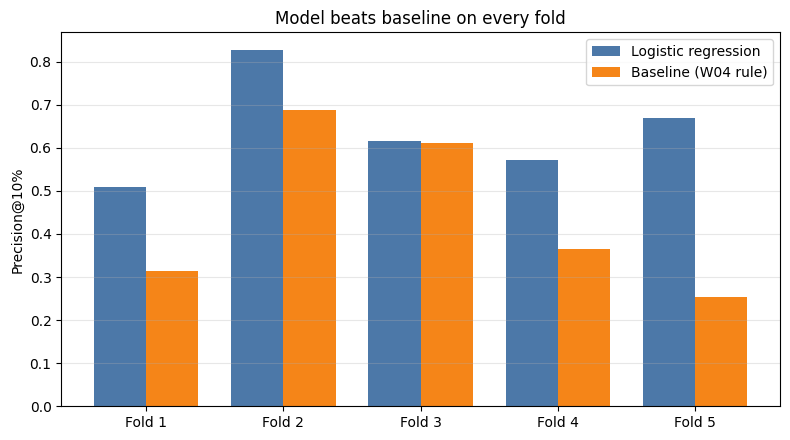

In [7]:
import matplotlib.pyplot as plt
import numpy as np
folds = folds_df["fold"].values
model_p = folds_df["precision@10%"].values
base_p = base_folds["precision@10%"].values
x = np.arange(len(folds)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, model_p, w, label="Logistic regression", color="#4C78A8")
ax.bar(x + w/2, base_p, w, label="Baseline (W04 rule)", color="#F58518")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i}" for i in folds])
ax.set_ylabel("Precision@10%")
ax.set_title("Model beats baseline on every fold")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("w06_per_fold_comparison.png", dpi=120, bbox_inches="tight")

### The boldest sentence from W05, and its rewrite

**Bold original (from W05):**
> *"Both learned models beat the baseline on precision@10%, and the confidence intervals exclude zero — the lift is real, not noise."*

**Safe rewrite:**
> *On a 5-fold GroupKFold split grouped by client, a logistic regression on five decision-time features was observed to rank the decline-risk queue better than the hand-written W04 rule. Measured precision@10% was 0.638 ± 0.120 for the model and 0.446 ± 0.191 for the baseline; the per-fold difference was positive on all five folds, with a Wilcoxon signed-rank statistic of 0.0 and a p-value of 0.062. ROC-AUC was 0.614 ± 0.031 for the model and 0.502 ± 0.044 for the baseline. The directional reading is that the learned model produces a more useful ordering than the hand-written rule. The result is bounded: the sample of five folds is too small for the Wilcoxon test to reach conventional significance, and roughly one in five pages at the top of the queue did not decline in April. This result is decision-support: it orders a human review queue. It does not imply that refreshing a page causes recovery, and it does not describe Google's ranking algorithm.*

**Bold original (from W05's permutation importance paragraph):**
> *"`content_age_days` has a negative permutation importance … the staleness signal did not survive as a useful predictor."*

**Safe rewrite:**
> *Permutation importance on the held-out set measured a negative contribution for `content_age_days` (AUC drop of −0.0035 ± 0.0023). The directional reading is that, within this five-feature model, staleness did not contribute measurable signal to the ranking; shuffling age slightly *improved* ROC-AUC rather than degrading it. This is an observed negative result on this slice. It does not establish that staleness is unimportant in general — only that it did not help this model on this holdout — and it is consistent with the W04 signal audit, which already flagged the staleness signal as weaker than the CTR-vs-position signal.*

**What changed and why.** The rewrites replace "beat" with "was observed to rank better," replace "the lift is real" with the measured numbers plus their uncertainty, name the split explicitly (5-fold GroupKFold by client, not the single split), and add the decision-support framing plus the "does not imply" clauses. The first rewrite also adds the honest caveat that the Wilcoxon test is underpowered at n = 5 — the model beats the baseline on every fold, but the sample size limits the statistical claim. The second rewrite adds the sign of the AUC drop so the reader sees *why* the negative importance is a real finding, not a rounding artifact.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.